# Lab: Regression Analysis

### Before you start:

* Read the README.md file
* Comment as much as you can and use the resources (README.md file) 

Happy learning!

## Challenge 1
I work at a coding bootcamp, and I have developed a theory that the younger my students are, the more often they are late to class. In order to test my hypothesis, I have collected some data in the following table:

| StudentID | Age | Tardies |
|--------|-----|------------|
| 1      | 17  | 10         |
| 2      | 51  | 1          |
| 3      | 27  | 5          |
| 4      | 21  | 9         |
| 5      | 36  |  4         |
| 6      | 48  |  2         |
| 7      | 19  |  9         |
| 8      | 26  | 6          |
| 9      | 54  |  0         |
| 10     | 30  |  3         |

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

Use this command to create a dataframe with the data provided in the table. 
~~~~
student_data = pd.DataFrame({'Age': [17,51,27,21,36,48,19,26,54,30], 'Tardies': [10,1,5,9,4,2,9,6,0,3]})
~~~~

In [2]:
# Your code here. 
student_data = pd.DataFrame({'Age': [17,51,27,21,36,48,19,26,54,30], 'Tardies': [10,1,5,9,4,2,9,6,0,3]})

Draw a dispersion diagram (scatter plot) for the data.

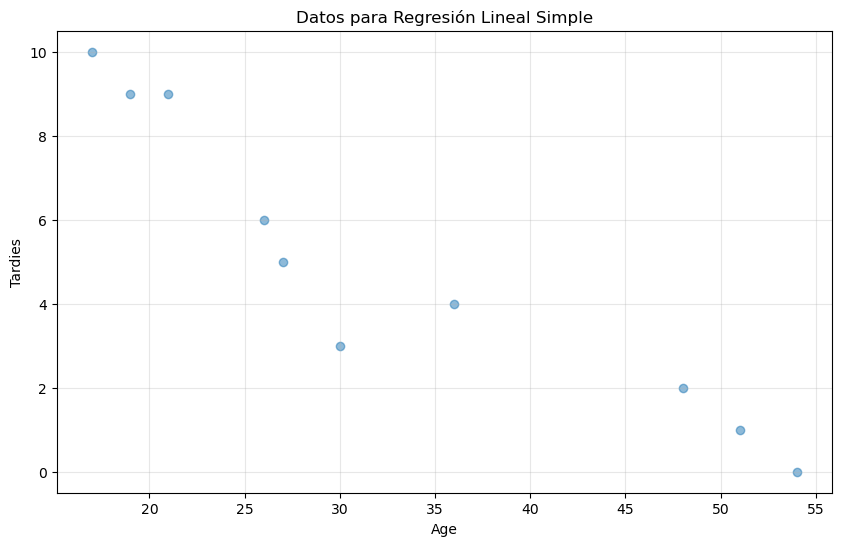

In [3]:
# Your code here
plt.figure(figsize=(10, 6))
plt.scatter(student_data.Age, student_data.Tardies, alpha=0.5)
plt.xlabel('Age')
plt.ylabel('Tardies')
plt.title('Datos para Regresión Lineal Simple')
plt.grid(True, alpha=0.3)
plt.show()

Do you see a trend? Can you make any hypotheses about the relationship between age and number of tardies?

*your explanation here*

Calculate the covariance and correlation of the variables in your plot. What is the difference between these two measures? Compare their values. What do they tell you in this case? Add your responses as comments after your code.

In [4]:
# your code here
covariance = np.cov(student_data.Age, student_data.Tardies)
correlation = student_data.Age.corr(student_data.Tardies)

print(f"""
    Covarianza: {covariance}
    Correlacion: {correlation}
""")


    Covarianza: [[187.65555556 -45.56666667]
 [-45.56666667  12.54444444]]
    Correlacion: -0.9391626886887122



Build a regression model for this data. What will be your outcome variable? What type of regression are you using? Add your responses as comments after your code.

In [5]:
# your explanation here
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X_age = student_data.Age.to_numpy().reshape(-1,1)
y_tard = student_data.Tardies.to_numpy().reshape(-1,1)

X_train, X_test, y_train, y_test = train_test_split(
    X_age, y_tard , 
    test_size=0.2,      # 20% para prueba, 80% para entrenamiento
    shuffle=True,       # Aleatoriedad de casas
    random_state=1   # Semilla para reproducibilidad
)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

w0_sklearn = modelo.intercept_
w1_sklearn = modelo.coef_[0]

print(f"""
    Parámetros previstos como optimos: 
        {w0_sklearn}
        {w1_sklearn}
""")

hw_test = modelo.predict(X_test)

mse = mean_squared_error(y_test, hw_test)

mse_test = mean_squared_error(y_test, hw_test)
r2_test = modelo.score(X_test, y_test)

print(f"MSE (Error Cuadrático Medio):     {mse_test:.4f}")
print(f"RMSE (Raíz del MSE):               {np.sqrt(mse_test):.4f}")
print(f"R² (Coeficiente de Determinación): {r2_test:.4f}")
print()
print(f"""En promedio, las predicciones del modelo
se desvían aproximadamente {np.sqrt(mse_test):.2f} unidades
de los valores reales.""")
print()
print(f"El modelo explica el {r2_test*100:.2f}% de la variabilidad de Y")


    Parámetros previstos como optimos: 
        [13.79125917]
        [-0.25488998]

MSE (Error Cuadrático Medio):     6.7667
RMSE (Raíz del MSE):               2.6013
R² (Coeficiente de Determinación): -5.7667

En promedio, las predicciones del modelo
se desvían aproximadamente 2.60 unidades
de los valores reales.

El modelo explica el -576.67% de la variabilidad de Y


Plot your regression model on your scatter plot.

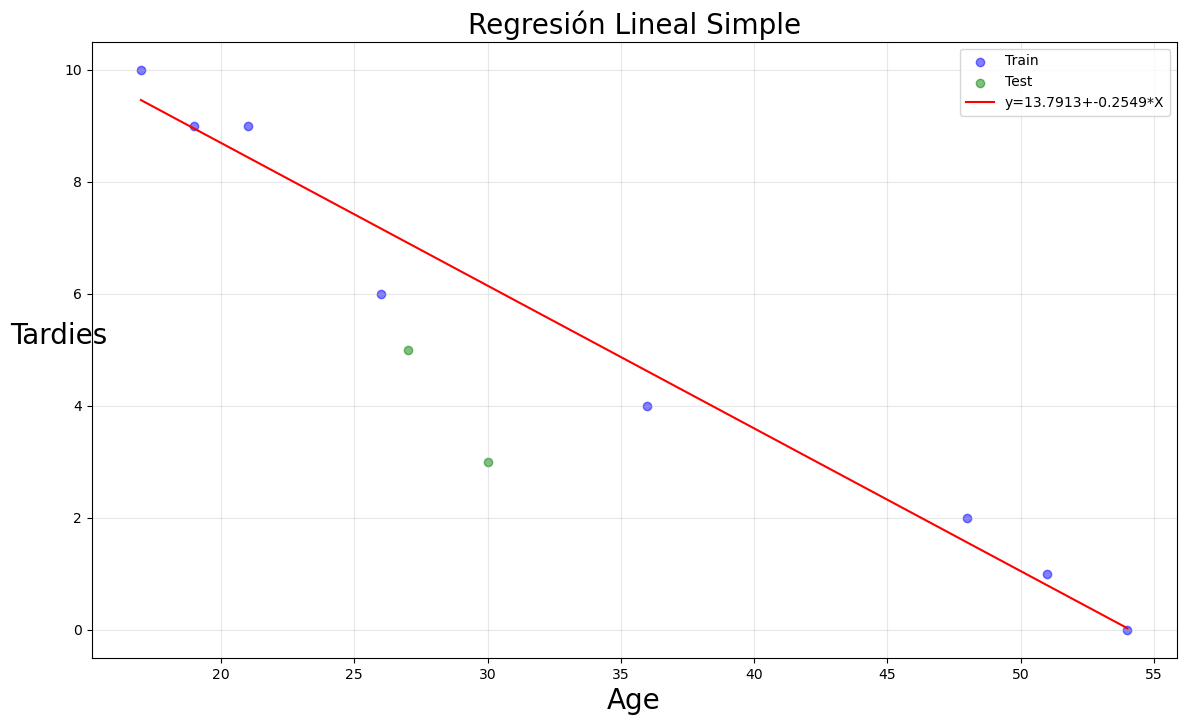

In [6]:
# Your code here.
plt.figure(figsize=(14, 8))

# Datos de entrenamiento vs Datos de prueba
plt.scatter(X_train, y_train, alpha=0.5, color='blue',  label='Train')
plt.scatter(X_test,  y_test,  alpha=0.5, color='green', label='Test')

# Línea de regresión.
# Creo 100 puntos equidistantes entre el mínimo de X (-10) y el máximo (10)
# La paso a matriz: es una matriz de 100 filas × 1 columna (valores -10 a 10)
# Luego uso predict sobre esa matriz para calcular una regresión perfecta.
X_linea = np.linspace(student_data.Age.min(), student_data.Age.max(), 100).reshape(-1, 1)
hw_linea = modelo.predict(X_linea)
plt.plot(X_linea, hw_linea, color='red', 
         label=f"y={w0_sklearn[0]:.4f}+{w1_sklearn[0]:.4f}*X")

plt.xlabel('Age', fontsize=20)
plt.ylabel('Tardies', fontsize=20, rotation=0)
plt.title('Regresión Lineal Simple', fontsize=20)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Interpret the results of your model. What can conclusions can you draw from your model and how confident in these conclusions are you? Can we say that age is a good predictor of tardiness? Add your responses as comments after your code.

*your explanation here*

No es un modelo fiable ya que tiene mucha tasa de error debido a poca cantidad de datos.

## Challenge 2
For the second part of this lab, we will use the vehicles.csv data set. You can find a copy of the dataset in the git hub folder. This dataset includes variables related to vehicle characteristics, including the model, make, and energy efficiency standards, as well as each car's CO2 emissions. As discussed in class the goal of this exercise is to predict vehicles' CO2 emissions based on several independent variables. 

In [7]:
# Import any libraries you may need & the data
vehicles = pd.read_csv("../vehicles.csv")
print(vehicles.shape)
print(vehicles.info())
vehicles.head()

(35952, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35952 entries, 0 to 35951
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Make                     35952 non-null  object 
 1   Model                    35952 non-null  object 
 2   Year                     35952 non-null  int64  
 3   Engine Displacement      35952 non-null  float64
 4   Cylinders                35952 non-null  float64
 5   Transmission             35952 non-null  object 
 6   Drivetrain               35952 non-null  object 
 7   Vehicle Class            35952 non-null  object 
 8   Fuel Type                35952 non-null  object 
 9   Fuel Barrels/Year        35952 non-null  float64
 10  City MPG                 35952 non-null  int64  
 11  Highway MPG              35952 non-null  int64  
 12  Combined MPG             35952 non-null  int64  
 13  CO2 Emission Grams/Mile  35952 non-null  float64
 14  Fuel Cost/

,Make,Model,Year,Engine Displacement,Cylinders,Transmission,Drivetrain,Vehicle Class,Fuel Type,Fuel Barrels/Year,City MPG,Highway MPG,Combined MPG,CO2 Emission Grams/Mile,Fuel Cost/Year
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,19.388824,18,17,17,522.764706,1950
1,AM General,FJ8c Post Office,1984,4.2,6.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
2,AM General,Post Office DJ5 2WD,1985,2.5,4.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,20.600625,16,17,16,555.437500,2100
3,AM General,Post Office DJ8 2WD,1985,4.2,6.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
4,ASC Incorporated,GNX,1987,3.8,6.0,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,20.600625,14,21,16,555.437500,2550


Let's use the following variables for our analysis: Year, Cylinders, Fuel Barrels/Year, Combined MPG, and Fuel Cost/Year. We will use 'CO2 Emission Grams/Mile' as our outcome variable. 

Calculate the correlations between each of these variables and the outcome. Which variable do you think will be the most important in determining CO2 emissions? Which provides the least amount of helpful information for determining CO2 emissions? Add your responses as comments after your code.

In [8]:
# Your code here.
outcome_variable = "CO2 Emission Grams/Mile"

correlation_year = vehicles[outcome_variable].corr(vehicles["Year"])
correlation_cylinders = vehicles[outcome_variable].corr(vehicles["Cylinders"])
correlation_fuel_barr_year = vehicles[outcome_variable].corr(vehicles["Fuel Barrels/Year"])
correlation_combined_mpg = vehicles[outcome_variable].corr(vehicles["Combined MPG"])
correlation_fuel_cost_year = vehicles[outcome_variable].corr(vehicles["Fuel Cost/Year"])


print(f"""
    Correlacion de emisiones C02 con:
    Año: {correlation_year:.4}
    Cilindros: {correlation_cylinders:.4f}
    Barriles fuel x año: {correlation_fuel_barr_year:.4f}
    Eficiencia: {correlation_combined_mpg:.4f}
    Coste fuel x año: {correlation_fuel_cost_year:.4f}
""")

# La mas decisiva para determinar el C02 emissions es la cantidad de fuel / año 
# La que menos parece estar relacionada es la del año


    Correlacion de emisiones C02 con:
    Año: -0.2223
    Cilindros: 0.7524
    Barriles fuel x año: 0.9862
    Eficiencia: -0.9262
    Coste fuel x año: 0.9309



Build a regression model for this data. What type of regression are you using? Add your responses as comments after your code.

In [9]:
# Your code here.
# Separamos features (variables X) y target (objetivo Y)
X_vehicles = vehicles[["Year","Cylinders","Fuel Barrels/Year","Combined MPG","Fuel Cost/Year"]]  # Todas las columnas (X) EXCEPTO Y
y_vehicles = vehicles['CO2 Emission Grams/Mile']        


X_train, X_test, y_train, y_test = train_test_split(
    X_vehicles, y_vehicles, 
    test_size=0.2, 
    random_state=1
)

# Vamos a usar regresión polinómica

In [10]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

# Transformamos train (desde X_train original, NO estandarizado)
X_train_poly = poly.fit_transform(X_train)

# Transformamos test
X_test_poly = poly.transform(X_test)

print(f"Features ORIGINALES:   {X_train.shape[1]} variables")
print(f"Features POLINÓMICAS:  {X_train_poly.shape[1]} variables")
print(f"Nuevas features:       {X_train_poly.shape[1] - X_train.shape[1]}")
print()


Features ORIGINALES:   5 variables
Features POLINÓMICAS:  20 variables
Nuevas features:       15



In [11]:
from sklearn.preprocessing import StandardScaler      # Z Score!

scaler = StandardScaler()
X_train_poly_scaled = scaler.fit_transform(X_train_poly) # Calcula y ajusta train
X_test_poly_scaled = scaler.transform(X_test_poly)       # Sólo ajusta a test


In [12]:
from sklearn.linear_model import SGDRegressor 
sgd_ridge = SGDRegressor(
    loss='squared_error',      
    penalty='l2',              
    alpha=0.003,               
    eta0=0.0001,               
    learning_rate='constant',  
    max_iter=1000,             
    tol=1e-3,                 
    random_state=1,     
    verbose=0        
)

sgd_ridge.fit(X_train_poly_scaled, y_train)


SGDRegressor(alpha=0.003, eta0=0.0001, learning_rate='constant', random_state=1)

Print your regression summary, and interpret the results. What are the most important varibles in your model and why? What can conclusions can you draw from your model and how confident in these conclusions are you? Add your responses as comments after your code.

In [13]:
y_train_pred_ridge = sgd_ridge.predict(X_train_poly_scaled)  # Predicciones
y_test_pred_ridge = sgd_ridge.predict(X_test_poly_scaled)   # Predicciones

mse_train_ridge = mean_squared_error(y_train, y_train_pred_ridge)
mse_test_ridge = mean_squared_error(y_test, y_test_pred_ridge)
r2_train_ridge = r2_score(y_train, y_train_pred_ridge)
r2_test_ridge = r2_score(y_test, y_test_pred_ridge) # Evaluaciones MSEyR2

print(f"MSE (train): {mse_train_ridge:.4f}")
print(f"MSE (test):  {mse_test_ridge:.4f}")
print(f"RMSE (train): {np.sqrt(mse_train_ridge):.4f}")
print(f"RMSE (test):  {np.sqrt(mse_test_ridge):.4f}")
print(f"R² (train):  {r2_train_ridge:.4f}")
print(f"R² (test):   {r2_test_ridge:.4f}")

MSE (train): 50.2169
MSE (test):  46.4007
RMSE (train): 7.0864
RMSE (test):  6.8118
R² (train):  0.9965
R² (test):   0.9967


## Bonus Challenge: Error Analysis

I am suspicious about the last few parties I have thrown: it seems that the more people I invite the more people are unable to attend. To know if my hunch is supported by data, I have decided to do an analysis. I have collected my data in the table below, where X is the number of people I invited, and Y is the number of people who attended. 

|  X |  Y |
|----|----|
| 1  |  1 |
| 3  |  2 |
| 4  |  4 |
| 6  |  4 |
| 8  |  5 |
| 9  |  7 |
| 11 |  8 |
| 14 |  13 |

We want to know if the relationship modeled by the two random variables is linear or not, and therefore if it is appropriate to model it with a linear regression. 
First, build a dataframe with the data. 

In [14]:
# Your code here.
party_data = pd.DataFrame({'X': [1,3,4,6,8,9,11,14], 'Y': [1,2,4,4,5,7,8,13]})

Draw a dispersion diagram (scatter plot) for the data, and fit a regression line.

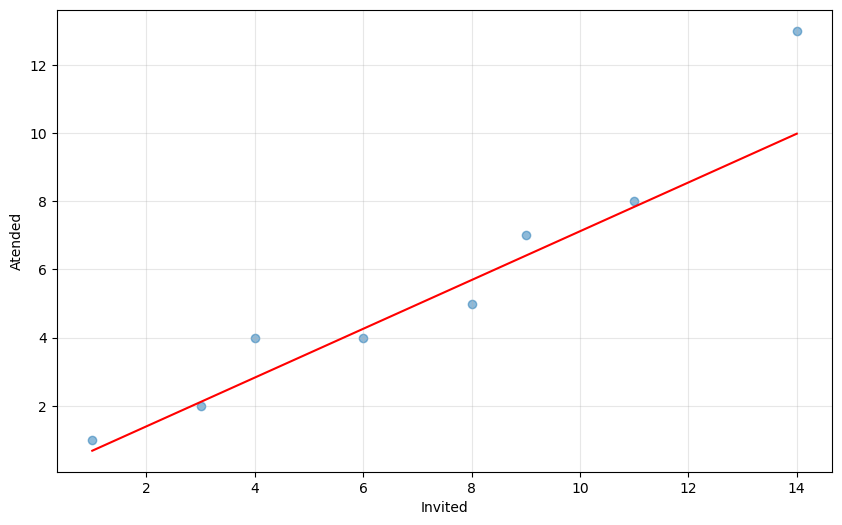

In [20]:
# Your code here.
X = party_data.X.to_numpy().reshape(-1,1)
y = party_data.Y.to_numpy().reshape(-1,1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y , 
    test_size=0.2,      # 20% para prueba, 80% para entrenamiento
    shuffle=True,       # Aleatoriedad de casas
    random_state=1   # Semilla para reproducibilidad
)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

X_linea = np.linspace(party_data.X.min(), party_data.X.max(), 100).reshape(-1, 1)
hw_linea = modelo.predict(X_linea)

# plot real data with regression line
plt.figure(figsize=(10, 6))
plt.plot(X_linea, hw_linea, color='red', 
         label=f"y={w0_sklearn[0]:.4f}+{w1_sklearn[0]:.4f}*X")
plt.scatter(party_data.X, party_data.Y, alpha=0.5)
plt.xlabel('Invited')
plt.ylabel('Atended')
plt.grid(True, alpha=0.3)
plt.show()

What do you see? What does this plot tell you about the likely relationship between the variables? Print the results from your regression.

*your explanation here*

Do you see any problematic points, or outliers, in your data? Remove these points and recalculate your regression. Print the new dispersion diagram with your new model and the results of your model. 

In [22]:
# Your response here.

What changed? Based on the results of the two models and your graphs, what can you say about the form of the data with the problematic point and without it?

*your explanation here*